In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pandas_datareader.data as web

**DOWNLOADING DATA FROM YFINANCE**

In [87]:
tickers = ['GS','MSCI','V','CRISIL.NS','HDFCBANK.NS']
data = yf.download(tickers=tickers,start='2019-01-01',end='2026-01-01')['Close']
data

/tmp/ipykernel_642/2009219871.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers=tickers,start='2019-01-01',end='2026-01-01')['Close']
[*********************100%***********************]  5 of 5 completed


Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Date,,,,,
2019-01-01,1430.624146,NaN,496.185883,NaN,NaN
2019-01-02,1435.571533,144.753738,491.658508,135.801636,126.068108
2019-01-03,1447.056152,142.633255,487.800964,130.626083,121.525024
2019-01-04,1436.808228,147.294846,489.106079,135.487381,126.760452
2019-01-07,1448.646362,148.111084,489.845245,136.115845,129.046234
...,...,...,...,...,...
2025-12-24,4240.708008,902.036438,980.975220,577.381165,353.675995
2025-12-26,4209.180664,898.332336,975.958191,580.596802,353.536530
2025-12-29,4254.050781,883.614990,975.564697,581.361023,353.148163


**EXPLORATORY DATA ANALYSIS**

In [88]:
data.isnull().sum().sum()

np.int64(340)

In [89]:
data.dropna(inplace=True)

In [90]:
data.isnull().sum().sum()

np.int64(0)

In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1674 entries, 2019-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CRISIL.NS    1674 non-null   float64
 1   GS           1674 non-null   float64
 2   HDFCBANK.NS  1674 non-null   float64
 3   MSCI         1674 non-null   float64
 4   V            1674 non-null   float64
dtypes: float64(5)
memory usage: 78.5 KB


In [92]:
data.describe()

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
count,1674.000000,1674.000000,1674.000000,1674.000000,1674.000000
mean,3003.211905,345.429292,704.001133,438.405093,229.404338
std,1348.592963,168.990250,140.511945,128.661170,58.349850
min,1028.493896,116.619843,357.657898,130.626083,121.525024
25%,1665.745178,198.522545,592.183167,348.079201,190.030121
50%,2915.264160,310.376740,708.663055,473.371155,214.961739
75%,4141.899170,387.118492,788.604034,543.495132,266.051224
max,6492.000488,902.284058,996.419800,640.888916,370.384399


In [93]:
returns = data.pct_change(fill_method=None).dropna()
returns

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Date,,,,,
2019-01-03,0.008000,-0.014649,-0.007846,-0.038111,-0.036037
2019-01-04,-0.007082,0.032682,0.002676,0.037215,0.043081
2019-01-07,0.008239,0.005542,0.001511,0.004639,0.018032
2019-01-08,-0.007196,-0.003693,-0.008323,0.020776,0.005439
2019-01-09,0.005927,0.006273,0.006562,0.009778,0.011769
...,...,...,...,...,...
2025-12-24,0.004330,0.010059,0.000602,0.000774,0.004981
2025-12-26,-0.007434,-0.004106,-0.005114,0.005569,-0.000394
2025-12-29,0.010660,-0.016383,-0.000403,0.001316,-0.001099


In [94]:
returns.shape

(1673, 5)

In [95]:
cov_matrix = returns.cov()
cov_matrix

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Ticker,,,,,
CRISIL.NS,0.000452,0.000034,0.000056,0.000037,0.000027
GS,0.000034,0.000418,0.000070,0.000205,0.000193
HDFCBANK.NS,0.000056,0.000070,0.000257,0.000047,0.000060
MSCI,0.000037,0.000205,0.000047,0.000463,0.000204
V,0.000027,0.000193,0.000060,0.000204,0.000272


In [96]:
corr_matrix = returns.corr()
corr_matrix

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Ticker,,,,,
CRISIL.NS,1.000000,0.077564,0.165054,0.080848,0.078261
GS,0.077564,1.000000,0.213199,0.466452,0.574016
HDFCBANK.NS,0.165054,0.213199,1.000000,0.135153,0.226517
MSCI,0.080848,0.466452,0.135153,1.000000,0.575411
V,0.078261,0.574016,0.226517,0.575411,1.000000


In [97]:
mean_returns = returns.mean()
mean_returns

,0
Ticker,
CRISIL.NS,0.000875
GS,0.001281
HDFCBANK.NS,0.000538
MSCI,0.001089
V,0.000745


In [98]:
weights = np.array([0.2,0.2,0.2,0.2,0.2])

In [99]:
portfolio_returns = weights @ mean_returns
print(f"The portfolio return is: {round(portfolio_returns,4)}")
portfolio_returns.shape

The portfolio return is: 0.0009


()

In [100]:
portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
print(f"The portfolio variance is: {round(portfolio_variance,4)}")

The portfolio variance is: 0.0001


In [101]:
portoflio_standard_deviation = np.sqrt(portfolio_variance)
print(f"The portfolio standard deviation is: {round(portoflio_standard_deviation,4)}")

The portfolio standard deviation is: 0.0122


**IMPLEMENTING SCIPY TO MINIMISE THE WEIGHTS**

In [102]:
from scipy.optimize import minimize

In [103]:
def calculate_portfolio_variance(weights,cov_matrix):
  return np.dot(weights.T, np.dot(cov_matrix, weights))

In [104]:
num_assets = 5
constraints = ({"type":"eq" , "fun": lambda w:np.sum(w) - 1})
bounds = tuple((0,1) for _ in range(num_assets))
initial_guess = num_assets * [1./num_assets]

In [105]:
results = minimize(calculate_portfolio_variance, initial_guess, args=(cov_matrix,), method='SLSQP', bounds=bounds, constraints=constraints,tol=1e-12)

In [106]:
min_var_weights = results.x
print(f"The minimum variance portfolio weights are: {min_var_weights}")

The minimum variance portfolio weights are: [0.21558415 0.0711694  0.36592452 0.07790957 0.26941237]


In [107]:
portfolio_returns = returns @ min_var_weights
print(f"The minimum variance portfolio returns are: {portfolio_returns}")

The minimum variance portfolio returns are: Date
2019-01-03   -0.014867
2019-01-04    0.016284
2019-01-07    0.007943
2019-01-08   -0.001776
2019-01-09    0.008058
                ...   
2025-12-24    0.003272
2025-12-26   -0.003439
2025-12-29    0.000791
2025-12-30   -0.007813
2025-12-31    0.003041
Length: 1673, dtype: float64


In [108]:
portfolio_returns.shape

(1673,)

**FEATURE ENGINEERING**

In [109]:
df = pd.DataFrame(index=portfolio_returns.index)
df['lagged_return'] = portfolio_returns.shift(1)
df['rolling_avg_10'] = portfolio_returns.rolling(10).mean().shift(1)
print(df.head())

            lagged_return  rolling_avg_10
Date                                     
2019-01-03            NaN             NaN
2019-01-04      -0.014867             NaN
2019-01-07       0.016284             NaN
2019-01-08       0.007943             NaN
2019-01-09      -0.001776             NaN


In [110]:
tickers = ['GS','MSCI','V','CRISIL.NS','HDFCBANK.NS']
volume_data = yf.download(tickers=tickers,start='2019-01-01',end='2026-01-01')['Volume']

/tmp/ipykernel_642/1056902159.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  volume_data = yf.download(tickers=tickers,start='2019-01-01',end='2026-01-01')['Volume']
[*********************100%***********************]  5 of 5 completed


In [111]:
print(volume_data.head())

Ticker      CRISIL.NS         GS  HDFCBANK.NS      MSCI           V
Date                                                               
2019-01-01     1390.0        NaN    6373440.0       NaN         NaN
2019-01-02    10263.0  3999400.0    8134232.0  637500.0   8788000.0
2019-01-03     5612.0  4060200.0   12771664.0  852100.0   9428300.0
2019-01-04     1522.0  3788300.0    7287120.0  599900.0  11065800.0
2019-01-07     6337.0  3152100.0    5387012.0  795300.0  12928000.0


In [112]:
volume_data.isnull().sum().sum()

np.int64(340)

In [113]:
volume_data.dropna(inplace=True)

In [114]:
volume_data.isnull().sum().sum()

np.int64(0)

In [115]:
df['rolling_vol_10'] = portfolio_returns.rolling(10).std().shift(1)
print(df.head())

            lagged_return  rolling_avg_10  rolling_vol_10
Date                                                     
2019-01-03            NaN             NaN             NaN
2019-01-04      -0.014867             NaN             NaN
2019-01-07       0.016284             NaN             NaN
2019-01-08       0.007943             NaN             NaN
2019-01-09      -0.001776             NaN             NaN


In [116]:
ff_daily = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start='2019-01-01', end='2026-01-01')[0] / 100
print(ff_daily.head())

            Mkt-RF     SMB     HML      RF
Date                                      
2019-01-02  0.0022  0.0058  0.0114  0.0001
2019-01-03 -0.0245  0.0036  0.0118  0.0001
2019-01-04  0.0355  0.0040 -0.0069  0.0001
2019-01-07  0.0094  0.0101 -0.0075  0.0001
2019-01-08  0.0101  0.0052 -0.0063  0.0001


In [117]:
def rolling_beta(window_returns, market_returns):
    if len(window_returns) < 2:
        return np.nan
    covariance = np.cov(window_returns, market_returns.loc[window_returns.index])[0,1]
    market_variance = np.var(market_returns.loc[window_returns.index])
    return covariance / market_variance

In [118]:
window = 60
rolling_betas = []

for i in range(len(portfolio_returns)):
    if i < window:
        rolling_betas.append(np.nan)
    else:
        window_returns = portfolio_returns.iloc[i-window:i]
        market_window = ff_daily['Mkt-RF'].reindex(window_returns.index)
        cov = np.cov(window_returns, market_window)[0,1]
        var = np.var(market_window)
        rolling_betas.append(cov/var)

df['rolling_beta_60'] = rolling_betas

In [119]:
ff_daily.index = ff_daily.index.to_timestamp()
print(ff_daily.index[:3])
print(ff_daily.index.dtype)

DatetimeIndex(['2019-01-02', '2019-01-03', '2019-01-04'], dtype='datetime64[ns]', name='Date', freq=None)
datetime64[ns]


In [120]:
rolling_cov = portfolio_returns.rolling(60).cov(ff_daily['Mkt-RF'])
rolling_market_var = ff_daily['Mkt-RF'].rolling(60).var()

df['rolling_beta_60'] = (rolling_cov / rolling_market_var).shift(1)

In [121]:
print(df['rolling_beta_60'].dropna().head())
print(df['rolling_beta_60'].isna().sum())

Date
2020-02-11    0.713372
2020-02-12    0.704726
2020-02-13    0.712257
2020-02-14    0.701829
2020-02-18    0.701178
Name: rolling_beta_60, dtype: float64
1599


In [122]:
df['rolling_var_60'] = portfolio_returns.rolling(60).quantile(0.05).shift(1)
print(df.head())

            lagged_return  rolling_avg_10  rolling_vol_10  rolling_beta_60  \
Date                                                                         
2019-01-03            NaN             NaN             NaN              NaN   
2019-01-04      -0.014867             NaN             NaN              NaN   
2019-01-07       0.016284             NaN             NaN              NaN   
2019-01-08       0.007943             NaN             NaN              NaN   
2019-01-09      -0.001776             NaN             NaN              NaN   

            rolling_var_60  
Date                        
2019-01-03             NaN  
2019-01-04             NaN  
2019-01-07             NaN  
2019-01-08             NaN  
2019-01-09             NaN  


In [123]:
df['target'] = (portfolio_returns.shift(-1) > 0).astype(int)
print(df.tail())

            lagged_return  rolling_avg_10  rolling_vol_10  rolling_beta_60  \
Date                                                                         
2025-12-24       0.002644        0.002393        0.009448              NaN   
2025-12-26       0.003272        0.003148        0.009153              NaN   
2025-12-29      -0.003439        0.000285        0.005051              NaN   
2025-12-30       0.000791       -0.000255        0.004619              NaN   
2025-12-31      -0.007813       -0.000635        0.005094              NaN   

            rolling_var_60  target  
Date                                
2025-12-24       -0.008443       0  
2025-12-26       -0.008443       1  
2025-12-29       -0.008443       0  
2025-12-30       -0.008443       1  
2025-12-31       -0.008443       0  


In [124]:
target_return = portfolio_returns.shift(-1)
df['target'] = np.where(target_return.isna(), np.nan, (target_return > 0).astype(int))

In [125]:
print(ff_daily.index.min(), ff_daily.index.max())
print(portfolio_returns.index.min(), portfolio_returns.index.max())

2019-01-02 00:00:00 2025-12-31 00:00:00
2019-01-03 00:00:00 2025-12-31 00:00:00


In [126]:
rolling_cov = portfolio_returns.rolling(60).cov(ff_daily['Mkt-RF'])
rolling_market_var = ff_daily['Mkt-RF'].rolling(60).var()
df['rolling_beta_60'] = (rolling_cov / rolling_market_var).shift(1)

print(df['rolling_beta_60'].isna().sum())
print(df['rolling_beta_60'].notna().sum())

1599
74


In [127]:
common_dates = portfolio_returns.index.intersection(ff_daily.index)
print(len(common_dates))
print(len(portfolio_returns))
print(len(ff_daily))

1673
1673
1760


In [128]:
ff_daily_aligned = ff_daily.loc[portfolio_returns.index]
print(ff_daily_aligned.shape)

rolling_cov = portfolio_returns.rolling(60).cov(ff_daily_aligned['Mkt-RF'])
rolling_market_var = ff_daily_aligned['Mkt-RF'].rolling(60).var()
df['rolling_beta_60'] = (rolling_cov / rolling_market_var).shift(1)

print(df['rolling_beta_60'].isna().sum())
print(df['rolling_beta_60'].notna().sum())

(1673, 4)
60
1613


In [129]:
df_clean = df.dropna()
print(df_clean.shape)
print(df_clean.head())

(1612, 6)
            lagged_return  rolling_avg_10  rolling_vol_10  rolling_beta_60  \
Date                                                                         
2019-04-05      -0.000257        0.000931        0.006178         0.511986   
2019-04-08       0.005768        0.001443        0.006361         0.495080   
2019-04-09       0.001265        0.002189        0.005776         0.516398   
2019-04-10      -0.004257        0.001856        0.006065         0.513958   
2019-04-11       0.001635        0.000875        0.005050         0.534471   

            rolling_var_60  target  
Date                                
2019-04-05       -0.008425     1.0  
2019-04-08       -0.008303     0.0  
2019-04-09       -0.008303     1.0  
2019-04-10       -0.008303     1.0  
2019-04-11       -0.008303     1.0  


**TRAIN/TEST SPLITTING**

In [130]:
x = df_clean.drop('target', axis=1)
y = df_clean['target']

In [131]:
from sklearn.model_selection import train_test_split

In [132]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,shuffle=False)

In [133]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1289, 5)
(1289,)
(323, 5)
(323,)


**IMPLEMENTING AN XGBOOST CLASSIFIER ON THE DATA**

In [134]:
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [135]:
model = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)

In [136]:
model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [154]:
print(y_test.index.is_monotonic_increasing)

True


In [137]:
y_pred = model.predict(x_test)

In [138]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.5077

Classification Report:
               precision    recall  f1-score   support

         0.0       0.49      0.28      0.36       158
         1.0       0.51      0.73      0.60       165

    accuracy                           0.51       323
   macro avg       0.50      0.50      0.48       323
weighted avg       0.50      0.51      0.48       323



In [139]:
print(confusion_matrix(y_test, y_pred))

[[ 44 114]
 [ 45 120]]


**BACKTESTING STRATEGY**

In [140]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [141]:
prediction_matrix = pd.DataFrame({
    "y_pred": y_pred,
})

In [142]:
exposure= np.where(prediction_matrix["y_pred"] == 1, 1.0, 0.5)

In [143]:
test_dates = y_test.index
actual_returns_test = portfolio_returns.loc[test_dates]
print(actual_returns_test.shape)

(323,)


In [144]:
strategy_returns = exposure * actual_returns_test.values
buy_and_hold_returns = actual_returns_test.values

print(strategy_returns[:10])
print(buy_and_hold_returns[:10])

[ 4.38233899e-03 -2.12640558e-03  4.70702847e-03  2.15267116e-04
  6.72111868e-03  2.06741119e-03 -2.87739336e-03 -2.70813305e-03
  6.98916091e-03 -2.85696322e-05]
[ 4.38233899e-03 -2.12640558e-03  4.70702847e-03  2.15267116e-04
  6.72111868e-03  2.06741119e-03 -2.87739336e-03 -2.70813305e-03
  6.98916091e-03 -2.85696322e-05]


In [145]:
strategy_cumulative_return = (1 + strategy_returns).cumprod() - 1
buy_and_hold_cumulative_return = (1 + buy_and_hold_returns).cumprod() - 1
print(strategy_cumulative_return)
print(buy_and_hold_cumulative_return)

[0.00438234 0.00224661 0.00696422 0.00718098 0.01395037 0.01604662
 0.01312305 0.01037938 0.01744109 0.01741202 0.01697505 0.02508379
 0.02756642 0.03627427 0.03583174 0.03543979 0.037064   0.04188767
 0.05137644 0.03738361 0.0314673  0.03811691 0.03668773 0.03708346
 0.0358999  0.01940745 0.01566375 0.00604543 0.01596586 0.01836001
 0.02385009 0.02930208 0.04246573 0.0394128  0.05595285 0.05125804
 0.05071424 0.06504387 0.05909228 0.06387691 0.07397233 0.06891085
 0.07399502 0.07695794 0.08841648 0.09216836 0.0931522  0.09078325
 0.09819087 0.11272328 0.10754753 0.11098602 0.11583914 0.10825718
 0.09218088 0.08884339 0.09799064 0.10549431 0.11760571 0.11622503
 0.12042766 0.12488775 0.13023649 0.13098724 0.13011971 0.12976758
 0.14089546 0.14026591 0.13869237 0.13744186 0.14768029 0.15032995
 0.15424027 0.1683002  0.16597951 0.15811518 0.14267408 0.14200463
 0.13983373 0.14222353 0.14535    0.14140737 0.14097576 0.14909466
 0.17584935 0.16139567 0.14958622 0.13113866 0.12960866 0.1219

In [146]:
cumulative_strat = pd.Series((1 + strategy_returns).cumprod())
cumulative_bh = pd.Series((1 + buy_and_hold_returns).cumprod())

max_drawdown_strat = (cumulative_strat / cumulative_strat.cummax() - 1).min()
max_drawdown_bh = (cumulative_bh / cumulative_bh.cummax() - 1).min()

print(max_drawdown_strat, max_drawdown_bh)

-0.11331410941772857 -0.12053915875210919


In [147]:
cumulative_return_strat = cumulative_strat.iloc[-1] - 1
cumulative_return_bh = cumulative_bh.iloc[-1] - 1

risk_free_rate = 0.02

sharpe_strat = (strategy_returns.mean() - risk_free_rate/252) / strategy_returns.std() * np.sqrt(252)
sharpe_bh = (buy_and_hold_returns.mean() - risk_free_rate/252) / buy_and_hold_returns.std() * np.sqrt(252)

print(f"Strategy: Cumulative Return {cumulative_return_strat:.4f}, Sharpe {sharpe_strat:.4f}")
print(f"Buy & Hold: Cumulative Return {cumulative_return_bh:.4f}, Sharpe {sharpe_bh:.4f}")

Strategy: Cumulative Return 0.2400, Sharpe 1.2944
Buy & Hold: Cumulative Return 0.2340, Sharpe 1.1415


In [148]:
np.random.seed(42)
random_predictions = np.random.choice([0, 1], size=len(y_test))
random_exposure = np.where(random_predictions == 1, 1.0, 0.5)

random_strategy_returns = random_exposure * actual_returns_test.values

In [149]:
random_strategy_cumulative_returns = (1 + random_strategy_returns).cumprod() - 1
print(f"Random strategy cumulative returns{random_strategy_cumulative_returns}")

Random strategy cumulative returns[ 2.19116950e-03  6.01046020e-05  2.41376029e-03  2.52165365e-03
  5.89068716e-03  7.97027683e-03  6.52011334e-03  5.15721814e-03
  8.66982092e-03  8.64100359e-03  8.42440156e-03  1.24446839e-02
  1.36706934e-02  1.79657396e-02  1.75310299e-02  1.73385158e-02
  1.89343387e-02  2.36736839e-02  3.29965716e-02  2.61224665e-02
  2.02703785e-02  2.35590922e-02  2.07408054e-02  2.15201048e-02
  2.03542973e-02  4.10935310e-03 -3.26569032e-03 -2.21437982e-02
 -2.85887953e-03 -5.09090343e-04  2.18508649e-03  7.52170617e-03
  2.04068109e-02  1.74184833e-02  3.36085392e-02  3.13108072e-02
  3.07773212e-02  3.78061899e-02  3.49064957e-02  3.72441816e-02
  4.21655281e-02  3.97097379e-02  4.46550138e-02  4.75369945e-02
  5.86824993e-02  6.23318905e-02  6.42458158e-02  6.30926592e-02
  7.03122363e-02  9.86392138e-02  9.60840941e-02  1.02889898e-01
  1.07707650e-01  9.26542231e-02  8.47292417e-02  8.14145283e-02
  9.04993639e-02  9.42256014e-02  1.00219574e-01  9.9539

In [150]:
random_sharpe_ratio = (random_strategy_returns.mean() / random_strategy_returns.std()) * np.sqrt(252)
print(f"Random Strategy Sharpe Ratio: {random_sharpe_ratio:.4f}")

Random Strategy Sharpe Ratio: 0.7411


In [151]:
cumulative_random = pd.Series((1 + random_strategy_returns).cumprod())
max_drawdown_random = (cumulative_random / cumulative_random.cummax() - 1).min()
print(f"Maximum Drawdown for Random Strategy: {max_drawdown_random:.4f}")

Maximum Drawdown for Random Strategy: -0.0846


**VISUALISATIONS**

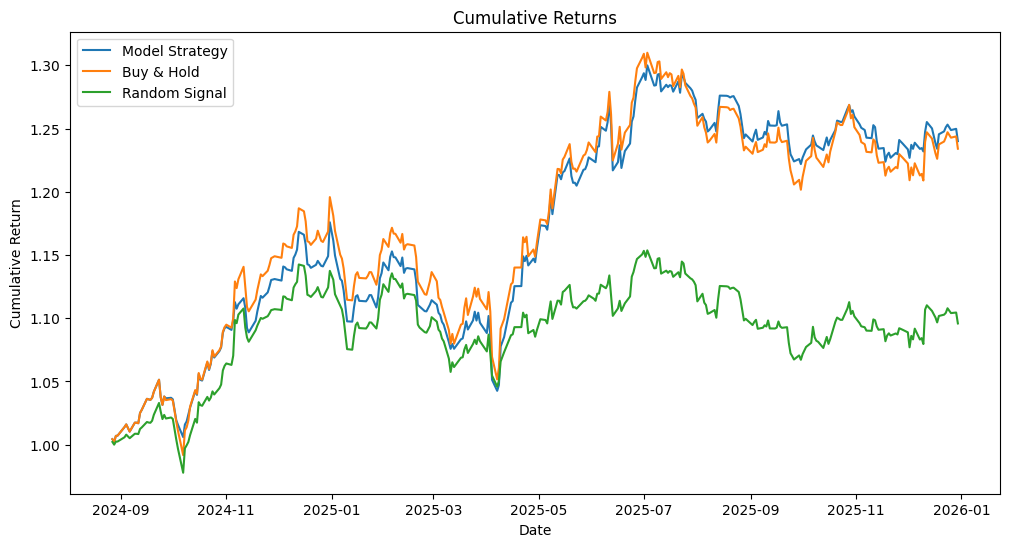

In [152]:
plt.figure(figsize=(12,6))
plt.plot(test_dates, cumulative_strat)
plt.plot(test_dates, cumulative_bh)
plt.plot(test_dates, cumulative_random)
plt.title("Cumulative Returns")
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(["Model Strategy", "Buy & Hold", "Random Signal"])

In [153]:
print(test_dates[:10])
print(test_dates.is_monotonic_increasing)

DatetimeIndex(['2024-08-27', '2024-08-28', '2024-08-29', '2024-08-30',
               '2024-09-03', '2024-09-04', '2024-09-05', '2024-09-06',
               '2024-09-09', '2024-09-10'],
              dtype='datetime64[ns]', name='Date', freq=None)
True
